# ex-h3 — linking the two dials by colour

*The idea being explored (N.):* keep $\{p_i\}$ (factor 1) and $\{q_i\}$ (factor 2) as two
separate point clouds in their original positions, but **link them by colour instead of
by geometry**, with the colour keyed to something meaningful rather than an arbitrary
index. Colour every $p_i$ by its own angle through a cyclic colormap, then give $q_i$
*that same $p_i$-derived colour*. If the $\approx 90^\circ$ relationship holds cleanly,
the $q$-cloud's colour pattern is the $p$-cloud's pattern **rotated a quarter turn**.
Where the correspondence breaks — colours bleeding into the wrong sector — is where the
pairing misbehaves, seen as a shape mismatch between two recognisably related colour
patterns rather than as 1000 illegible lines.

**Why this is worth doing, in one table.** The marginal clouds are nearly *invariant* in
$p$ — the angular spread of each cloud sits at $\approx 4.4^\circ$ whether $p$ is 500 or
50,000. But the *pairing* tightens by two orders of magnitude over the same range. The
shape of either cloud therefore carries almost no information about pairing quality; the
colour link is the only thing in the picture that can show it. That is the case for the
method, and §1 prints the numbers behind it.

**One deviation from the brief.** `DiskDensity` / `draw_disk_kde` map *density* to colour,
so they cannot key hue to a per-point value — two calls to them would give two
density heatmaps, not a colour correspondence. §2 defines a small `hue_density` layer
instead: same smoothed-density-on-a-disk idea, but **hue** carries the $p_i$-derived
angle and **alpha** carries the density.

In [1]:
import sys
from io import BytesIO
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "sim").is_dir():
    if REPO_ROOT == REPO_ROOT.parent:
        raise FileNotFoundError("could not locate repo root (no 'sim' dir above cwd)")
    REPO_ROOT = REPO_ROOT.parent
for _p in (str(REPO_ROOT), str(REPO_ROOT / "sim"), str(REPO_ROOT / "hedging")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

from loguru import logger
logger.remove()

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm, colors as mcolors
from scipy.ndimage import gaussian_filter
from IPython.display import Image, display

from fl_plot import THEME, draw_disk_frame, save as save_fig
from fl_experiment_setup import ModelSpec, DesignSpec, BaseExperiment, build_model, simulate_returns
from fl_experiment_runner import run_experiment
from factor_lab.analyses.spectral import compute_true_eigenvalues
from hedge_lab import sample_pcs

OUT_DIR = REPO_ROOT / "nb_outputs" / "hedging"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_FORMATS, SAVE_FIGS = ("pdf",), False

def out(stem, save=None):
    return OUT_DIR / stem if (SAVE_FIGS if save is None else save) else None

def show(fig, stem=None, save=None):
    p = out(stem, save) if stem else None
    if p is not None:
        save_fig(fig, p, formats=FIG_FORMATS)
    buf = BytesIO(); fig.savefig(buf, format="png", dpi=115, bbox_inches="tight")
    display(Image(data=buf.getvalue())); plt.close(fig)

CYCLIC = "twilight"          # cyclic colormap for the angle key ('hsv' is the vivid alternative)
plt.rcParams.update({"figure.dpi": 115})

K = 2
model_spec = ModelSpec(
    k_factors=K, factor_vols=[0.16, 0.08],
    beta_samplers=[{"distribution": "normal", "loc": 1.0, "scale": 0.5},
                   {"distribution": "normal", "loc": 0.0, "scale": 1.0}],
    idio_vol_sampler={"distribution": "constant", "value": 0.4},
)
HEAVY_TAIL = dict(
    factor_return_sampler={"distribution": "student_t", "df": 6, "loc": 0.0, "scale": 1.0},
    idio_return_sampler={"distribution": "student_t", "df": 5, "loc": 0.0, "scale": 1.0},
)
P_GRID, N_REPS, SEED = [100, 500, 5000, 50_000], 1000, 20260511
print("ready")

ready


## 1 · The paired sweep, and why the colour link is needed

Same shared-$B$ design as everywhere else here. Each replicate contributes a *pair*:
$p_i=\Pi h_1$ and $q_i=\Pi h_2$ in the $(\bar b_1,\bar b_2)$ plane, gauge-fixed so each
$h_j$ points into its own $\bar b_j$.

In [2]:
def gauge(b_pop, B, H):
    sb = np.sign(np.einsum("jp,jp->j", b_pop, B[:b_pop.shape[0]]))
    b_pop = b_pop * np.where(sb == 0, 1.0, sb)[:, None]
    sh = np.sign(np.diag(b_pop @ H))
    return b_pop, H * np.where(sh == 0, 1.0, sh)[None, :]


class CoordAnalysis:
    # Per-replicate arrow coordinates C = B_bar H, gauge-fixed.
    def __init__(self, b_pop, B):
        self.b_pop, self.B = b_pop, B

    def analyze(self, context) -> dict:
        Y = context.security_returns.T
        Y = Y - Y.mean(axis=1, keepdims=True)
        H, _, _ = sample_pcs(Y, context.k, center=False)
        b_pop, H = gauge(self.b_pop, self.B, H)
        return {"C": b_pop @ H}


class CoordExperiment(BaseExperiment):
    def cell_setup(self, model, n, p):
        _, b_pop = compute_true_eigenvalues(model, model.k)
        return [CoordAnalysis(b_pop, model.B)]

    def record(self, n, p, merged):
        C = merged["C"]
        return [{"n": n, "p": p, "j": j + 1, "hb1": float(C[0, j]), "hb2": float(C[1, j]),
                 "oos": float(1.0 - (C[:, j] ** 2).sum())} for j in range(C.shape[1])]


design = DesignSpec(n_values=[63], p_values=P_GRID, n_reps=N_REPS, random_seed=SEED,
                    sampling="nested", nest_time=True, shared_loadings=True, **HEAVY_TAIL)
# A cache is only usable if it matches THIS design. Checking mere existence is how a
# stale or unrelated parquet gets silently served (it happened while building this
# notebook), so validate the schema and the grid before trusting it.
_REQ = {"n", "p", "j", "hb1", "hb2", "oos", "rep"}
_pq = OUT_DIR / "h3_paired_dial_colours.parquet"

def load_or_run(path, design):
    if path.exists():
        d = pd.read_parquet(path)
        if (_REQ <= set(d.columns)
                and sorted(d["p"].unique()) == sorted(design.p_values)
                and sorted(d["n"].unique()) == sorted(design.n_values)
                and int(d.groupby(["n", "p", "j"]).size().max()) == design.n_reps):
            print(f"loaded cached sweep {path.name} ({len(d):,} rows)")
            return d
        print(f"{path.name} does not match this design (columns or grid) — re-running")
    print("running sweep (about two minutes)...")
    d = run_experiment(model_spec, design, CoordExperiment(), progress=True)
    d.to_parquet(path)
    print(f"ran sweep ({len(d):,} rows) -> {path.name}")
    return d

df = load_or_run(_pq, design)


def wrap(a):
    # radians into (-pi, pi]
    return (a + np.pi) % (2 * np.pi) - np.pi


P = df[df.j == 1].set_index(["rep", "p"]).sort_index()
Q = df[df.j == 2].set_index(["rep", "p"]).sort_index()
pair = pd.DataFrame({
    "px": P.hb1, "py": P.hb2, "qx": Q.hb1, "qy": Q.hb2,
    "oos_p": P.oos, "oos_q": Q.oos,
}).reset_index()
pair["theta_p"] = np.arctan2(pair.py, pair.px)
pair["theta_q"] = np.arctan2(pair.qy, pair.qx)
pair["delta"] = wrap(pair.theta_q - pair.theta_p - np.pi / 2)      # departure from a clean 90 deg
pair["cross"] = pair.px * pair.qx + pair.py * pair.qy              # <Pi h_1, Pi h_2>

summary = (pair.groupby("p")
           .apply(lambda g: pd.Series({
               "theta_p spread (deg)": np.degrees(g.theta_p.std()),
               "theta_q spread (deg)": np.degrees(g.theta_q.std()),
               "delta spread (deg)": np.degrees(g.delta.std()),
               "|delta| 95th pct (deg)": np.degrees(g.delta.abs().quantile(0.95)),
           }), include_groups=False))
display(summary.round(3))
print("The two marginal spreads barely move across p; the pairing spread collapses.\n"
      f"delta spread shrinks {summary['delta spread (deg)'].iloc[0] / summary['delta spread (deg)'].iloc[-1]:.0f}x "
      "while the clouds themselves look essentially the same.")

running sweep (about two minutes)...


replicate:   0%|          | 0/1000 [00:00<?, ?rep/s]

replicate:   0%|          | 1/1000 [00:00<03:18,  5.03rep/s]

replicate:   0%|          | 2/1000 [00:00<02:28,  6.71rep/s]

replicate:   0%|          | 3/1000 [00:00<02:11,  7.59rep/s]

...

replicate: 100%|██████████| 1000/1000 [01:59<00:00,  7.58rep/s]

replicate: 100%|██████████| 1000/1000 [01:59<00:00,  8.34rep/s]

ran sweep (8,000 rows) -> h3_paired_dial_colours.parquet


,theta_p spread (deg),theta_q spread (deg),delta spread (deg),|delta| 95th pct (deg)
p,,,,
100,5.235,9.921,8.302,5.672
500,4.836,4.982,1.140,1.076
5000,4.361,4.368,0.160,0.319
50000,4.398,4.397,0.052,0.103


The two marginal spreads barely move across p; the pairing spread collapses.
delta spread shrinks 161x while the clouds themselves look essentially the same.


## 2 · The colour key and the hue-density layer

$\theta_p$ occupies a narrow arc (spread $\approx 4.4^\circ$), so keying a cyclic map to
the **full circle** would render both clouds effectively monochrome and show nothing.
The key is therefore wound around a *window* centred on the circular mean of $\theta_p$,
wide enough to hold essentially all of it. Within that window the map is still cyclic, so
its two ends meet — a caveat worth stating: points at opposite extremes of the window get
similar colours. They are rare by construction, and every claim made from colour below is
also made numerically in §4.

In [3]:
HALF_WIDTH = np.radians(14.0)      # +/- window for the colour key (about 3 sd of theta_p)
CENTER = float(np.arctan2(np.sin(pair.theta_p).mean(), np.cos(pair.theta_p).mean()))

def key_to_unit(theta):
    # angle -> [0,1] position on the cyclic colormap, wound around CENTER.
    return (wrap(theta - CENTER) / (2 * HALF_WIDTH) + 0.5).clip(0, 1)

def hue_density(ax, xy, key_theta, *, gridsize=240, sigma=3.2, radius=1.0,
                alpha_max=0.95, floor=0.035, cmap=CYCLIC):
    # Smoothed density layer on the disk whose HUE is the circular mean of key_theta
    # among the points in each cell, and whose ALPHA is the local density.
    x, y = np.asarray(xy[:, 0]), np.asarray(xy[:, 1])
    rng = [[-radius, radius], [-radius, radius]]
    cnt, _, _ = np.histogram2d(x, y, bins=gridsize, range=rng)
    sn, _, _ = np.histogram2d(x, y, bins=gridsize, range=rng, weights=np.sin(key_theta))
    cs, _, _ = np.histogram2d(x, y, bins=gridsize, range=rng, weights=np.cos(key_theta))
    cnt, sn, cs = (gaussian_filter(a, sigma) for a in (cnt, sn, cs))
    mean_theta = np.arctan2(sn, cs)

    rgba = plt.get_cmap(cmap)(key_to_unit(mean_theta))
    dens = cnt / cnt.max() if cnt.max() > 0 else cnt
    a = np.clip((dens ** 0.55 - floor) / (1 - floor), 0, 1) * alpha_max
    gx = gy = (np.arange(gridsize) + 0.5) / gridsize * 2 * radius - radius
    RR = np.hypot(*np.meshgrid(gx, gy, indexing="ij"))
    a[RR > radius] = 0.0
    rgba[..., 3] = a
    ax.imshow(np.transpose(rgba, (1, 0, 2)), origin="lower",
              extent=(-radius, radius, -radius, radius), interpolation="bilinear", zorder=3)
    return mean_theta, cnt


def colour_key(fig, ax_anchor, label=r"colour key: $\theta_p$ (deg from the cloud centre)"):
    sm = cm.ScalarMappable(cmap=CYCLIC, norm=mcolors.Normalize(
        -np.degrees(HALF_WIDTH), np.degrees(HALF_WIDTH)))
    cb = fig.colorbar(sm, ax=ax_anchor, orientation="horizontal", fraction=0.04, pad=0.06)
    cb.set_label(label, fontsize=9.5, color=THEME.gray)
    cb.ax.tick_params(labelsize=8.5)
    return cb

print(f"key centred at {np.degrees(CENTER):.3f} deg, half-width {np.degrees(HALF_WIDTH):.0f} deg")

key centred at 0.039 deg, half-width 14 deg


## 3 · The two clouds on one disk, linked by colour

Both layers on a single disk, exactly as proposed: $p$ near $\bar b_1$, $q$ near
$\bar b_2$, so they occupy different sectors and do not paint over each other. **Hue is
$\theta_p$ in both layers** — the $q$ layer is wearing its partner's colour.

Read it like this: the $p$ layer is the reference fan (its hue *is* its own angle, so it
varies smoothly with position). If the quarter-turn relation is exact, the $q$ layer is
the same fan rotated $90^\circ$. At $p=100$ it is visibly not; by $p=50{,}000$ it is.

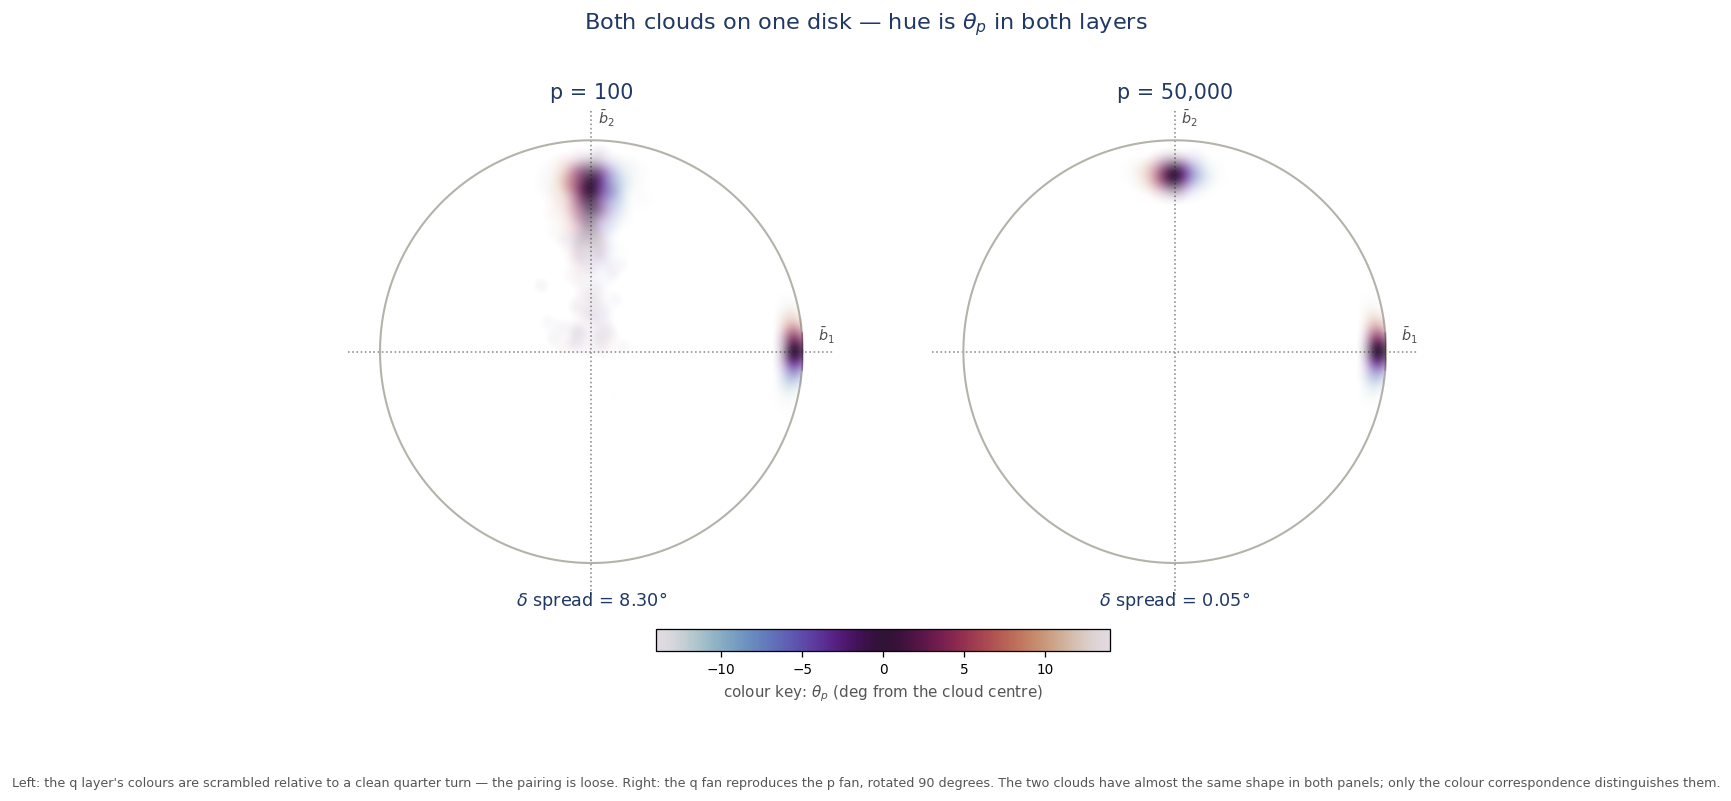

In [4]:
def dial(ax, sub, title=None):
    draw_disk_frame(ax, labels=(r"$\bar b_1$", r"$\bar b_2$"))
    hue_density(ax, sub[["px", "py"]].to_numpy(), sub.theta_p.to_numpy())
    hue_density(ax, sub[["qx", "qy"]].to_numpy(), sub.theta_p.to_numpy())
    if title:
        ax.set_title(title, fontsize=THEME.title_fontsize, color=THEME.navy)

_SHOW = [100, 50_000]
fig, axes = plt.subplots(1, len(_SHOW), figsize=(6.0 * len(_SHOW), 6.4))
for ax, p in zip(axes, _SHOW):
    s = pair[pair.p == p]
    dial(ax, s, f"p = {p:,}")
    ax.text(0, -1.20, rf"$\delta$ spread = {np.degrees(s.delta.std()):.2f}$\degree$",
            ha="center", fontsize=11, color=THEME.navy)
colour_key(fig, list(axes))
fig.suptitle(r"Both clouds on one disk — hue is $\theta_p$ in both layers",
             fontsize=THEME.title_fontsize + 1, color=THEME.navy)
fig.text(0.5, -0.06, "Left: the q layer's colours are scrambled relative to a clean quarter turn — the pairing is "
                     "loose. Right: the q fan reproduces the p fan, rotated 90 degrees. The two clouds have almost "
                     "the same shape in both panels; only the colour correspondence distinguishes them.",
         ha="center", va="top", fontsize=THEME.caption_fontsize, color=THEME.gray)
show(fig, "h3_fig1_one_disk_colour_link")

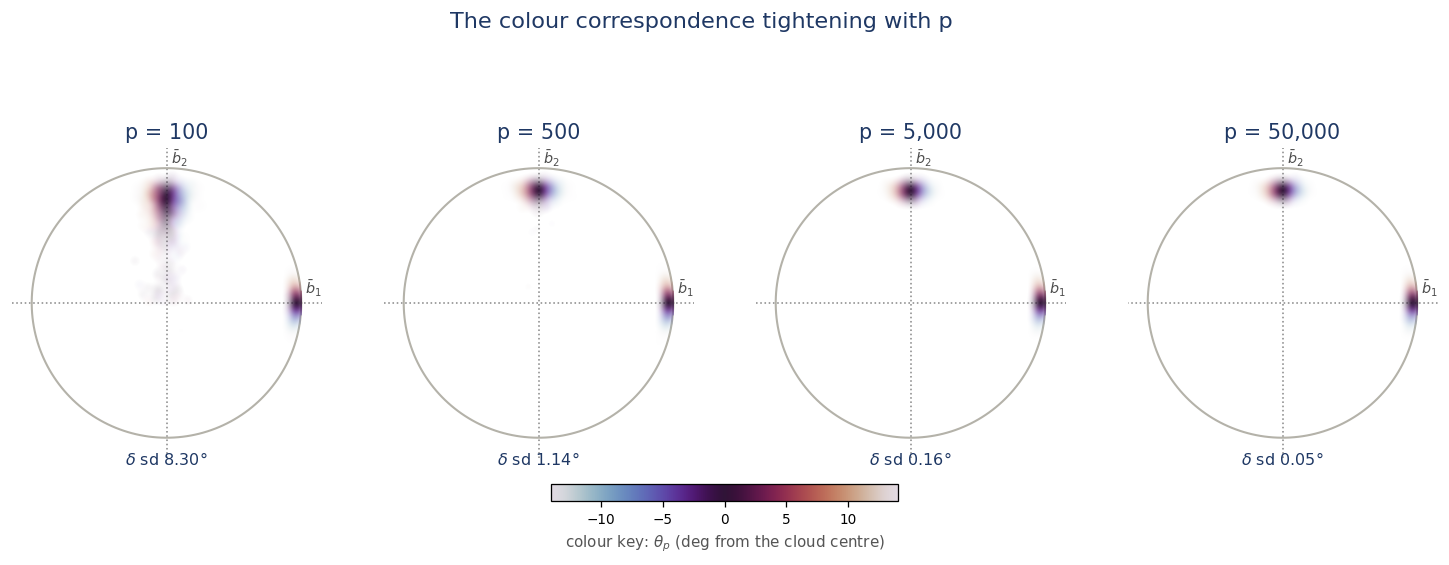

In [5]:
# ── The same view across the whole p grid ────────────────────────────────────
fig, axes = plt.subplots(1, len(P_GRID), figsize=(4.0 * len(P_GRID), 4.9))
for ax, p in zip(axes, P_GRID):
    s = pair[pair.p == p]
    dial(ax, s, f"p = {p:,}")
    ax.text(0, -1.20, rf"$\delta$ sd {np.degrees(s.delta.std()):.2f}$\degree$",
            ha="center", fontsize=10, color=THEME.navy)
colour_key(fig, list(axes))
fig.suptitle("The colour correspondence tightening with p",
             fontsize=THEME.title_fontsize + 1, color=THEME.navy)
show(fig, "h3_fig2_colour_link_over_p")

## 4 · The quarter-turn test, made explicit

Rotating the $q$ cloud by $-90^\circ$ should land it on the $p$ cloud, colours and all.
The left panel below does exactly that; the right panel is the honest version of "colours
bleeding into the wrong sector" — the per-cell difference between the rotated $q$ layer's
hue field and the $p$ layer's, in degrees. Grey means the two agree; saturated colour
marks a region where the pairing is not a clean quarter turn.

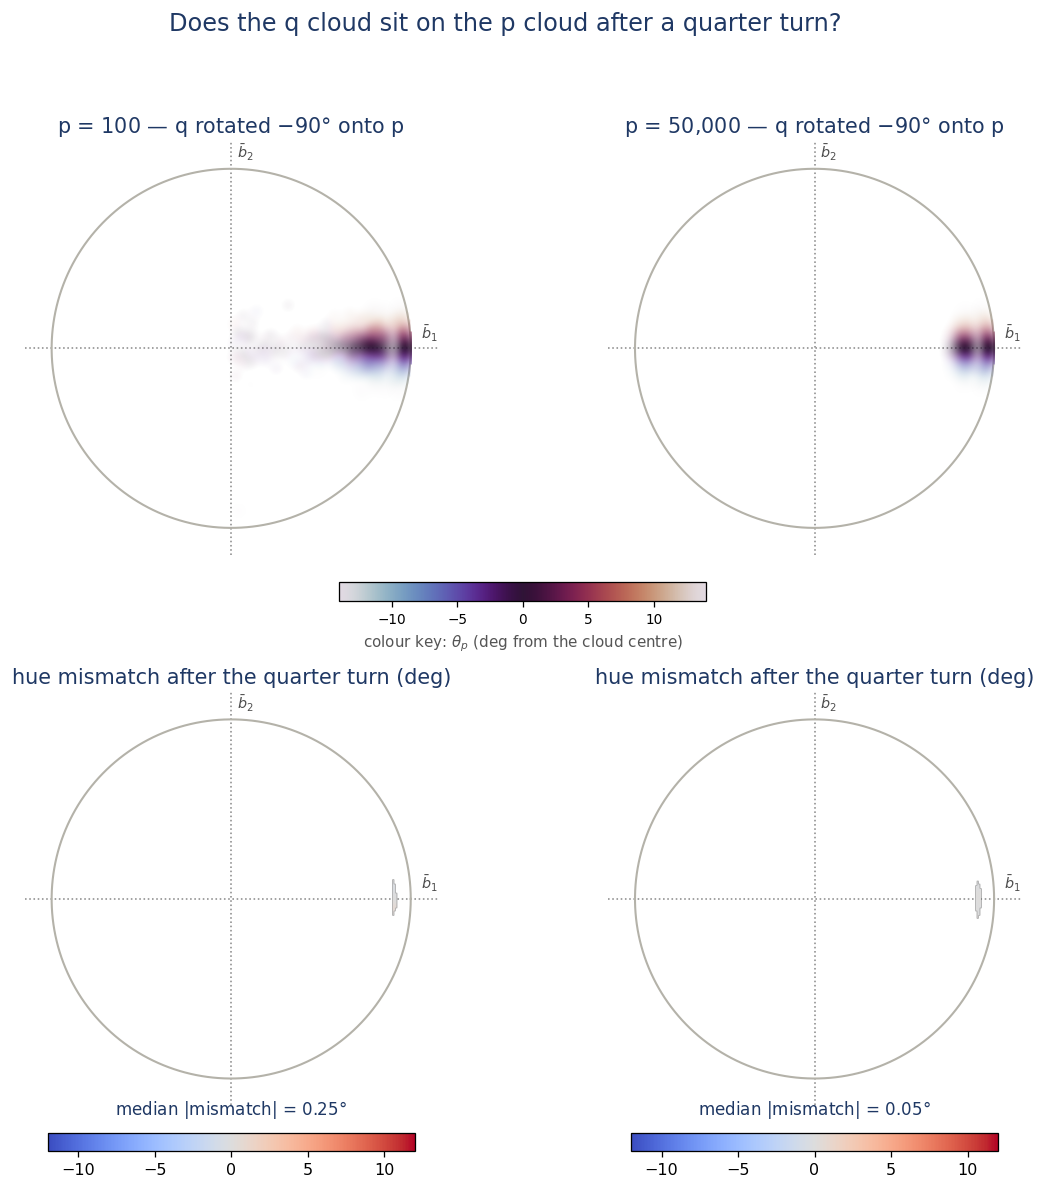

In [6]:
def rotate(xy, deg):
    t = np.radians(deg); c, s = np.cos(t), np.sin(t)
    return xy @ np.array([[c, s], [-s, c]])

def hue_field(sub, which):
    # Return the (mean theta_p, density) field of one cloud, q optionally pre-rotated.
    xy = sub[["px", "py"]].to_numpy() if which == "p" else rotate(sub[["qx", "qy"]].to_numpy(), -90)
    fig_, ax_ = plt.subplots()
    f = hue_density(ax_, xy, sub.theta_p.to_numpy())
    plt.close(fig_)
    return f

fig, axes = plt.subplots(2, len(_SHOW), figsize=(6.0 * len(_SHOW), 11.4))
for col, p in enumerate(_SHOW):
    s = pair[pair.p == p]
    ax = axes[0, col]
    draw_disk_frame(ax, labels=(r"$\bar b_1$", r"$\bar b_2$"))
    hue_density(ax, s[["px", "py"]].to_numpy(), s.theta_p.to_numpy())
    hue_density(ax, rotate(s[["qx", "qy"]].to_numpy(), -90), s.theta_p.to_numpy())
    ax.set_title(f"p = {p:,} — q rotated $-90\\degree$ onto p",
                 fontsize=THEME.title_fontsize, color=THEME.navy)

    (mp, cp), (mq, cq) = hue_field(s, "p"), hue_field(s, "q")
    both = (cp > cp.max() * 0.06) & (cq > cq.max() * 0.06)
    diff = np.degrees(wrap(mq - mp))
    ax = axes[1, col]
    draw_disk_frame(ax, labels=(r"$\bar b_1$", r"$\bar b_2$"))
    D = np.where(both, diff, np.nan)
    im = ax.imshow(D.T, origin="lower", extent=(-1, 1, -1, 1), cmap="coolwarm",
                   vmin=-12, vmax=12, interpolation="bilinear", zorder=3)
    ax.set_title(f"hue mismatch after the quarter turn (deg)",
                 fontsize=THEME.title_fontsize, color=THEME.navy)
    ax.text(0, -1.20, f"median |mismatch| = {np.nanmedian(np.abs(D)):.2f}$\\degree$",
            ha="center", fontsize=10.5, color=THEME.navy)
    fig.colorbar(im, ax=ax, orientation="horizontal", fraction=0.04, pad=0.06)
colour_key(fig, list(axes[0]))
fig.suptitle("Does the q cloud sit on the p cloud after a quarter turn?",
             fontsize=THEME.title_fontsize + 2, color=THEME.navy)
show(fig, "h3_fig3_quarter_turn_test")

## 5 · What actually drives the departure — an exact identity

The colour picture says *where* the quarter turn fails. This says *why*, and it is exact
rather than empirical. $h_1$ and $h_2$ are orthonormal, so splitting each into its
in-plane and out-of-plane parts,

$$0=\langle h_1,h_2\rangle=\langle \Pi h_1,\Pi h_2\rangle+\langle \Pi^{\perp}h_1,\Pi^{\perp}h_2\rangle
\quad\Longrightarrow\quad
\boxed{\;\langle \Pi h_1,\Pi h_2\rangle=-\langle \Pi^{\perp}h_1,\Pi^{\perp}h_2\rangle\;}$$

The two dial arrows fail to be orthogonal by **exactly minus the inner product of their
out-of-subspace parts**. The quarter turn is not approximately true for a vague reason —
it is true to the extent that the out-of-plane components of the two estimates are
uncorrelated. The cell below checks the identity directly on one replicate, then uses it
across the sweep.

In [7]:
# Direct check on one replicate: compute both sides from the p-dimensional vectors.
rng = np.random.default_rng(SEED)
_model = build_model(model_spec, 5_000, rng)
_ctx = simulate_returns(_model, 63, HEAVY_TAIL["factor_return_sampler"],
                        HEAVY_TAIL["idio_return_sampler"], K, rng)
_Y = _ctx.security_returns.T
_Y = _Y - _Y.mean(axis=1, keepdims=True)
_H, _, _ = sample_pcs(_Y, K, center=False)
_, _b = compute_true_eigenvalues(_model, K)
_b, _H = gauge(_b, _model.B, _H)

Pi_h = _b @ _H                                  # (2,2): in-plane coordinates
perp = _H - _b.T @ (_b @ _H)                    # (p,2): out-of-plane parts
lhs = float(Pi_h[:, 0] @ Pi_h[:, 1])
rhs = float(-(perp[:, 0] @ perp[:, 1]))
print(f"<Pi h_1, Pi h_2>            = {lhs:+.12f}")
print(f"-<Pi_perp h_1, Pi_perp h_2> = {rhs:+.12f}")
print(f"|difference|                = {abs(lhs - rhs):.2e}   (h_1.h_2 = {_H[:,0] @ _H[:,1]:+.1e})")
print(f"angle between the dial arrows = "
      f"{np.degrees(np.arccos(np.clip(lhs / np.linalg.norm(Pi_h[:,0]) / np.linalg.norm(Pi_h[:,1]), -1, 1))):.3f} deg")

<Pi h_1, Pi h_2>            = +0.003639499781
-<Pi_perp h_1, Pi_perp h_2> = +0.003639499781
|difference|                = 1.93e-16   (h_1.h_2 = -2.2e-16)
angle between the dial arrows = 89.748 deg


In [8]:
# Across the sweep: the departure from 90 deg is the cross term, rescaled.
pair["pred_delta"] = -pair.cross / (np.hypot(pair.px, pair.py) * np.hypot(pair.qx, pair.qy))
chk = (pair.assign(resid=lambda d: np.degrees(np.arcsin(d.pred_delta.clip(-1, 1)) - d.delta))
           .groupby("p").resid.apply(lambda s: s.abs().max()))
print("max |arcsin(cross term) - delta| per p, in degrees "
      "(they are the same quantity, so this is a numerical check):")
display(chk.round(10))

display(pair.groupby("p").agg(
    delta_sd_deg=("delta", lambda s: np.degrees(s.std())),
    cross_sd=("cross", "std"),
    mean_oos_p=("oos_p", "mean"),
    mean_oos_q=("oos_q", "mean"),
).round(5))
print("The out-of-subspace masses barely move in p — but their two components decorrelate,\n"
      "and that decorrelation is what drives the cross term, hence delta, to zero.")

max |arcsin(cross term) - delta| per p, in degrees (they are the same quantity, so this is a numerical check):


p
100      0.0
500      0.0
5000     0.0
50000    0.0
Name: resid, dtype: float64

,delta_sd_deg,cross_sd,mean_oos_p,mean_oos_q
p,,,,
100,8.30182,0.02720,0.08337,0.45486
500,1.14032,0.00849,0.08107,0.30599
5000,0.15972,0.00220,0.07977,0.30537
50000,0.05165,0.00072,0.07985,0.30085


The out-of-subspace masses barely move in p — but their two components decorrelate,
and that decorrelation is what drives the cross term, hence delta, to zero.


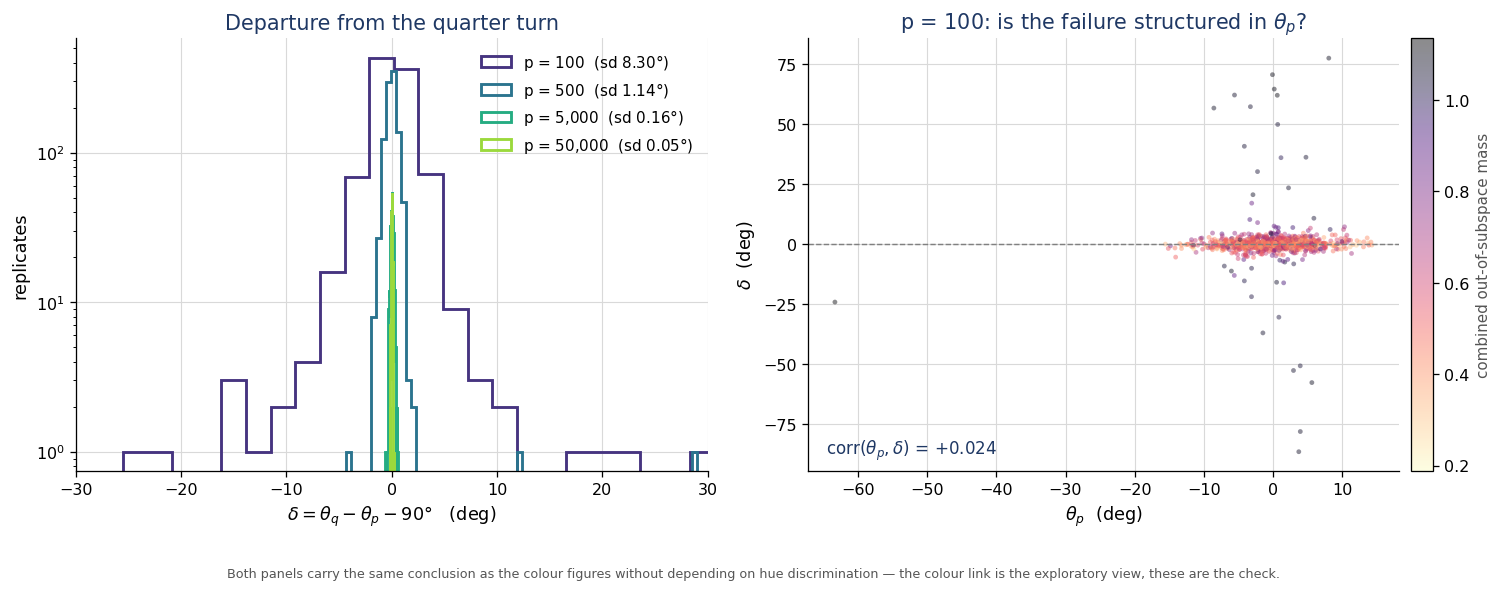

In [9]:
# ── Figure 4 · where the pairing misbehaves, without relying on colour vision ─
fig, axes = plt.subplots(1, 2, figsize=(13.2, 4.8))

ax = axes[0]
for p, c in zip(P_GRID, plt.get_cmap("viridis")(np.linspace(0.15, 0.85, len(P_GRID)))):
    s = pair[pair.p == p]
    ax.hist(np.degrees(s.delta), bins=70, histtype="step", lw=1.8, color=c,
            label=f"p = {p:,}  (sd {np.degrees(s.delta.std()):.2f}$\\degree$)")
ax.set_xlim(-30, 30); ax.set_yscale("log")
ax.set_xlabel(r"$\delta=\theta_q-\theta_p-90\degree$   (deg)", fontsize=THEME.label_fontsize)
ax.set_ylabel("replicates", fontsize=THEME.label_fontsize)
ax.set_title("Departure from the quarter turn", fontsize=THEME.title_fontsize, color=THEME.navy)
ax.legend(fontsize=9.5, frameon=False)
ax.grid(color=THEME.grid_color, lw=0.7); ax.set_axisbelow(True)
for sp in ("top", "right"): ax.spines[sp].set_visible(False)

ax = axes[1]
s = pair[pair.p == 100]
sc = ax.scatter(np.degrees(s.theta_p), np.degrees(s.delta), s=9, alpha=0.45, lw=0,
                c=s.oos_p + s.oos_q, cmap="magma_r")
ax.axhline(0, color="0.5", lw=0.9, ls="--")
ax.set_xlabel(r"$\theta_p$  (deg)", fontsize=THEME.label_fontsize)
ax.set_ylabel(r"$\delta$  (deg)", fontsize=THEME.label_fontsize)
ax.set_title(r"p = 100: is the failure structured in $\theta_p$?",
             fontsize=THEME.title_fontsize, color=THEME.navy)
cb = fig.colorbar(sc, ax=ax, fraction=0.045, pad=0.02)
cb.set_label("combined out-of-subspace mass", fontsize=9.5, color=THEME.gray)
ax.grid(color=THEME.grid_color, lw=0.7); ax.set_axisbelow(True)
for sp in ("top", "right"): ax.spines[sp].set_visible(False)
_r = np.corrcoef(np.degrees(s.theta_p), np.degrees(s.delta))[0, 1]
ax.text(0.03, 0.04, rf"corr$(\theta_p,\delta)$ = {_r:+.3f}", transform=ax.transAxes,
        fontsize=10.5, color=THEME.navy)

fig.tight_layout()
fig.text(0.5, -0.04, "Both panels carry the same conclusion as the colour figures without depending on hue "
                     "discrimination — the colour link is the exploratory view, these are the check.",
         ha="center", va="top", fontsize=THEME.caption_fontsize, color=THEME.gray)
show(fig, "h3_fig4_delta_diagnostics")

## 6 · Reading

**The method works, and earns its place.** The two marginal clouds are nearly identical
at every $p$ — same angular spread, same shape — while the pairing tightens by two orders
of magnitude. Nothing about either cloud's *shape* reveals that; the colour link does, and
it does so without drawing a single connecting line.

**What it shows here.** At $p=100$ the $q$ layer's colours are scrambled relative to a
quarter turn. By $p=50{,}000$ the $q$ fan is the $p$ fan rotated $90^\circ$, and the hue
mismatch map goes flat.

**Why, exactly.** $\langle\Pi h_1,\Pi h_2\rangle=-\langle\Pi^{\perp}h_1,\Pi^{\perp}h_2\rangle$,
verified to $\sim10^{-16}$ in §5. The quarter turn holds precisely to the extent that the
two estimates' *out-of-subspace* parts are uncorrelated — so the departure is not noise
around $90^\circ$, it is a readout of a specific inner product. Note this is not the same
as the out-of-subspace mass shrinking: those masses barely move in $p$; it is their
*correlation* that dies.

**Caveats.**

- A cyclic map over a narrow window has its two ends meeting, so extreme-$\theta_p$ points
  get similar colours. Rare by construction, and §4 repeats every claim numerically.
- Cyclic colormaps are the weakest case for colour-vision deficiency. Figure 4 is the
  colour-independent version of the same finding, deliberately.
- Hue in a density cell is a *circular mean* over the points in it. Where a cell mixes two
  genuinely different $\theta_p$ populations, the mean is a fiction — the mismatch map in
  §4 masks low-density cells for this reason, but it cannot detect a bimodal cell.